In [ ]:
!pip install -q torchvision scikit-learn scikit-image seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 25.2 MB/s eta 0:00:00


## EMNIST DIGITS

100%|██████████| 562M/562M [00:06<00:00, 82.8MB/s]


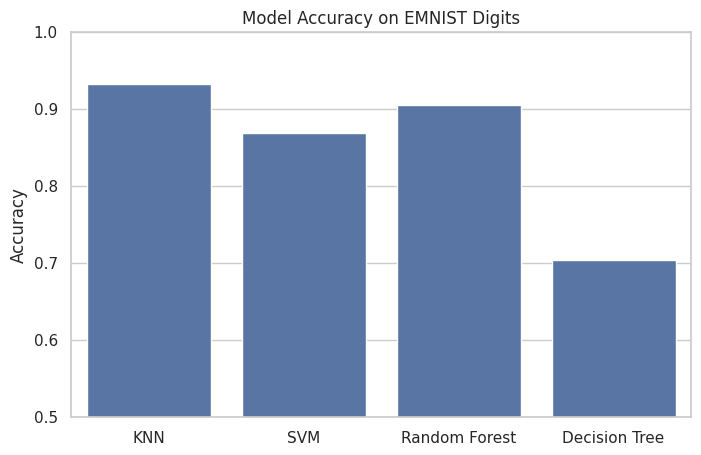

--- KNN ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       104
           1       0.91      0.96      0.93        90
           2       0.91      0.95      0.93        73
           3       0.93      0.87      0.90       103
           4       0.97      0.91      0.94        99
           5       0.93      0.90      0.92       102
           6       0.99      0.97      0.98       109
           7       0.93      0.96      0.94       114
           8       0.94      0.88      0.91        99
           9       0.90      0.93      0.91       107

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



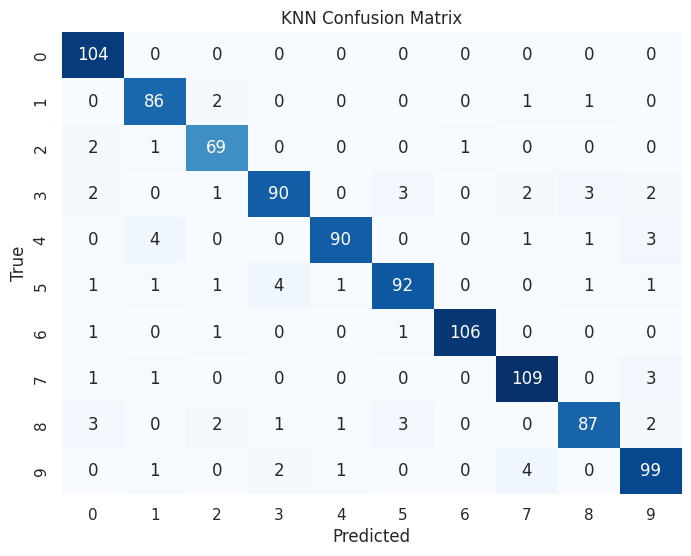

--- SVM ---
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       104
           1       0.99      0.93      0.96        90
           2       0.40      1.00      0.57        73
           3       0.97      0.73      0.83       103
           4       0.99      0.84      0.91        99
           5       0.94      0.86      0.90       102
           6       1.00      0.93      0.96       109
           7       0.97      0.86      0.91       114
           8       0.94      0.83      0.88        99
           9       0.98      0.86      0.92       107

    accuracy                           0.87      1000
   macro avg       0.92      0.87      0.88      1000
weighted avg       0.93      0.87      0.89      1000



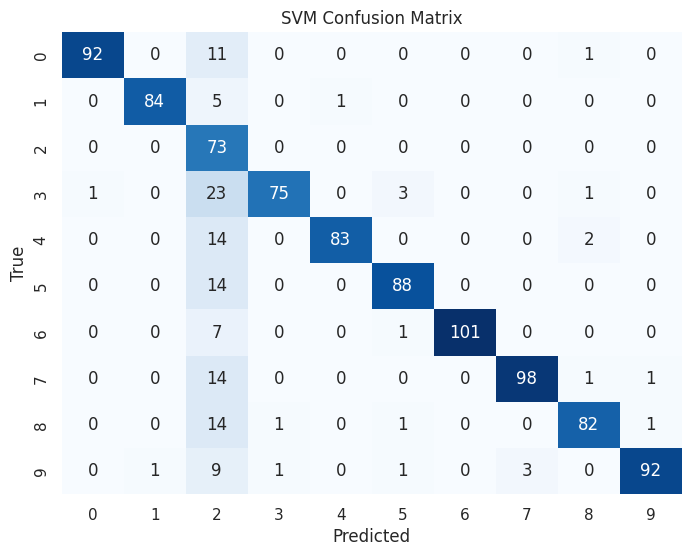

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       104
           1       0.98      0.92      0.95        90
           2       0.87      0.92      0.89        73
           3       0.91      0.88      0.90       103
           4       0.91      0.87      0.89        99
           5       0.94      0.90      0.92       102
           6       0.95      0.96      0.95       109
           7       0.93      0.89      0.91       114
           8       0.82      0.85      0.83        99
           9       0.85      0.88      0.87       107

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.90      1000
weighted avg       0.91      0.91      0.91      1000



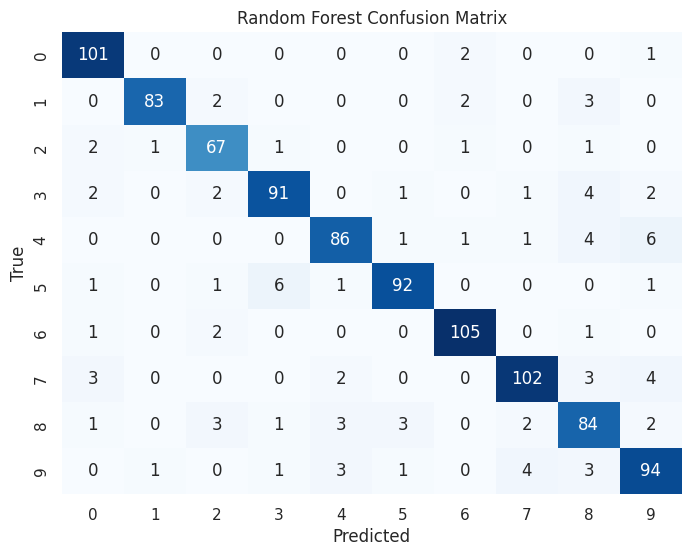

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       104
           1       0.91      0.87      0.89        90
           2       0.63      0.71      0.67        73
           3       0.70      0.68      0.69       103
           4       0.70      0.64      0.67        99
           5       0.65      0.65      0.65       102
           6       0.82      0.78      0.80       109
           7       0.70      0.68      0.69       114
           8       0.58      0.63      0.60        99
           9       0.63      0.63      0.63       107

    accuracy                           0.70      1000
   macro avg       0.71      0.71      0.71      1000
weighted avg       0.71      0.70      0.70      1000



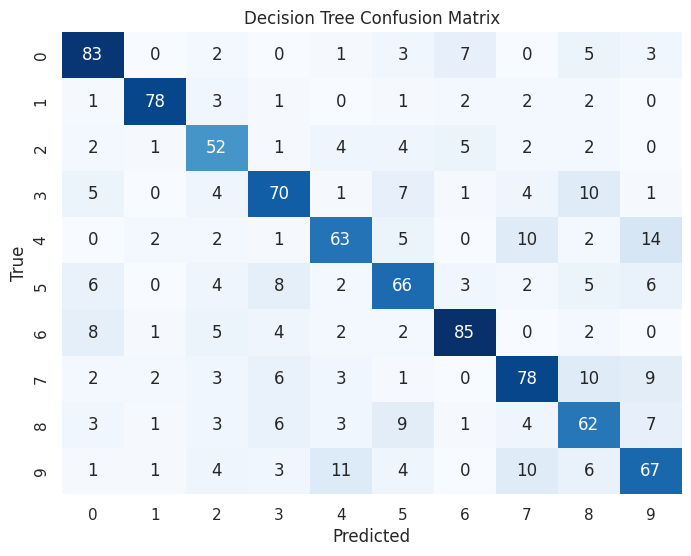

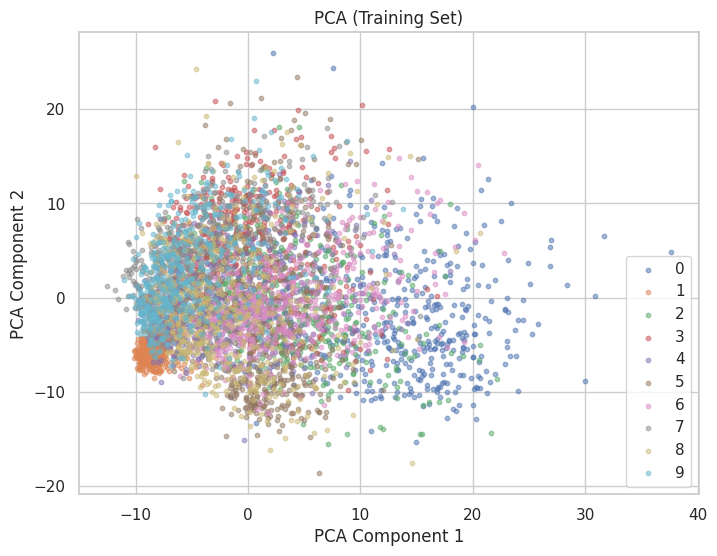

In [ ]:
# EMNIST subset - Digits

# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from torchvision.datasets import EMNIST
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.tree import DecisionTreeClassifier

# Load EMNIST Digits dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = EMNIST(root="./data", split="digits", train=True, download=True, transform=transform)
test_dataset = EMNIST(root="./data", split="digits", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=5000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=True)

train_images, train_labels = next(iter(train_loader))
test_images, test_labels = next(iter(test_loader))

X_train = train_images.squeeze().numpy()
X_test = test_images.squeeze().numpy()
y_train = train_labels.numpy()
y_test = test_labels.numpy()

X_train = X_train.reshape((X_train.shape[0], -1)) / 255.0
X_test = X_test.reshape((X_test.shape[0], -1)) / 255.0

# Standardize + PCA
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# Train Models
results = {}

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train)
y_pred_knn = knn.predict(X_test_pca)
results['KNN'] = accuracy_score(y_test, y_pred_knn)

# SVM
svm = SVC(kernel='rbf', C=10, gamma=0.01)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)
results['SVM'] = accuracy_score(y_test, y_pred_svm)

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)
results['Random Forest'] = accuracy_score(y_test, y_pred_rf)

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=25, random_state=42)
dt.fit(X_train_pca, y_train)
y_pred_dt = dt.predict(X_test_pca)
results['Decision Tree'] = accuracy_score(y_test, y_pred_dt)

# Plot Accuracy Comparison
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylim(0.5, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Accuracy on EMNIST Digits")
plt.show()

# Classification Report & Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("SVM", y_test, y_pred_svm)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Decision Tree", y_test, y_pred_dt)

# Visualize PCA-Reduced Space
def plot_pca_scatter(X_pca, y, title):
    plt.figure(figsize=(8, 6))
    for digit in np.unique(y):
        idx = y == digit
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"{digit}", alpha=0.5, s=10)
    plt.legend()
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True)
    plt.show()

plot_pca_scatter(X_train_pca, y_train, "PCA (Training Set)")


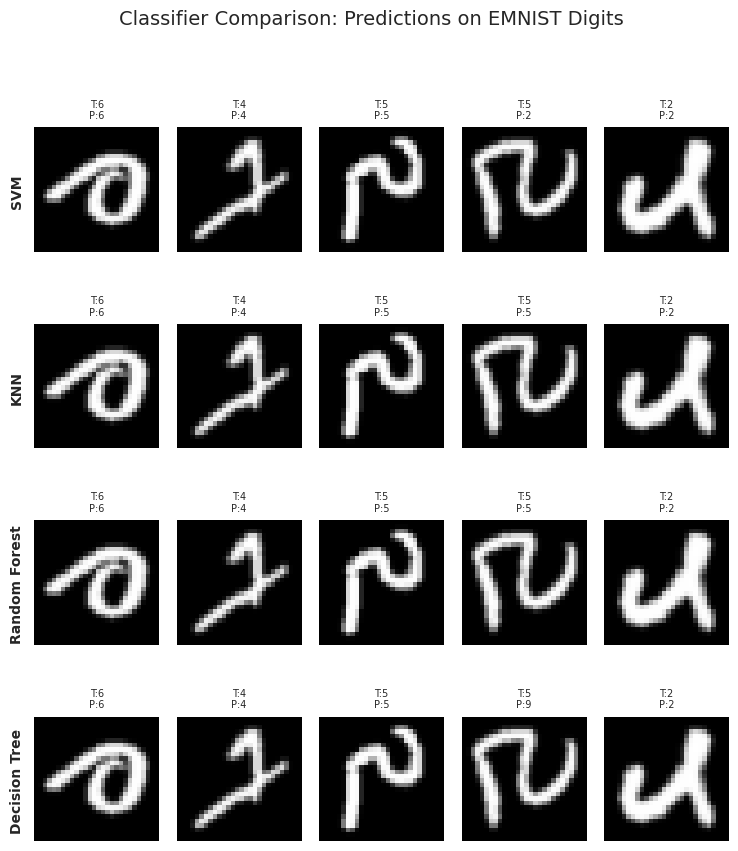

In [ ]:
sample_images = test_images.squeeze().numpy()

def show_model_comparison_subplots(images, y_true, predictions, sample_indices=None, num_samples=5):

    model_names = list(predictions.keys())
    assert len(model_names) == 4,

    if sample_indices is None:
        sample_indices = np.random.choice(len(images), size=num_samples, replace=False)

    fig, axes = plt.subplots(4, num_samples, figsize=(num_samples * 1.5, 9))

    for row, model_name in enumerate(model_names):
        y_pred = predictions[model_name]

        for col, idx in enumerate(sample_indices):
            ax = axes[row, col]
            img = images[idx].reshape(28, 28) if images[idx].ndim == 1 else images[idx]
            ax.imshow(img, cmap='gray')
            ax.set_title(f"T:{y_true[idx]}\nP:{y_pred[idx]}", fontsize=7)
            ax.axis('off')

        # Add row title once on the left
        axes[row, 0].text(-6, 14, model_name, fontsize=10, weight='bold', va='center', rotation=90)

    plt.suptitle("Classifier Comparison: Predictions on EMNIST Digits", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

predictions = {
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "Decision Tree": y_pred_dt
}

show_model_comparison_subplots(sample_images, y_test, predictions, num_samples=5)




## EMNIST Dataset - subset - Balanced

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


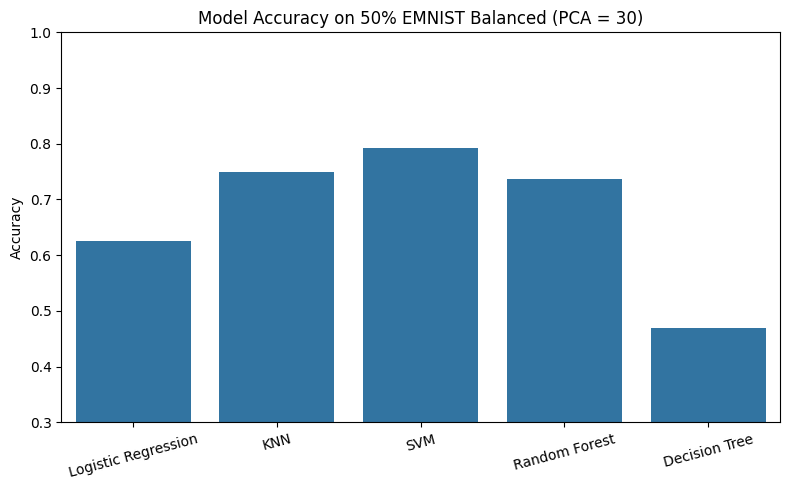

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.57      0.62      0.60       200
           1       0.47      0.58      0.52       200
           2       0.67      0.71      0.69       200
           3       0.80      0.86      0.83       200
           4       0.59      0.62      0.61       200
           5       0.62      0.55      0.58       200
           6       0.72      0.80      0.76       200
           7       0.81      0.89      0.85       200
           8       0.67      0.62      0.64       200
           9       0.54      0.65      0.59       200
          10       0.63      0.58      0.60       200
          11       0.71      0.60      0.65       200
          12       0.68      0.74      0.71       200
          13       0.74      0.69      0.71       200
          14       0.65      0.62      0.63       200
          15       0.45      0.39      0.41       200
          16       0.78      0.64      0.70       200

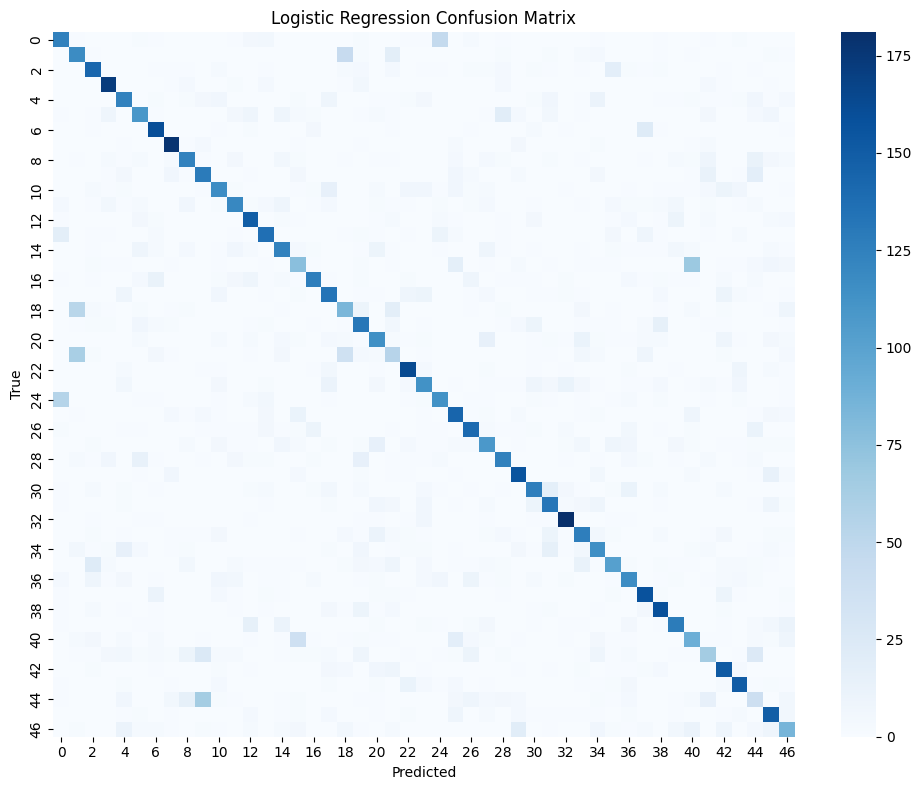

--- KNN ---
              precision    recall  f1-score   support

           0       0.47      0.59      0.52       200
           1       0.47      0.68      0.55       200
           2       0.75      0.79      0.77       200
           3       0.80      0.94      0.87       200
           4       0.73      0.86      0.79       200
           5       0.71      0.73      0.72       200
           6       0.80      0.89      0.84       200
           7       0.86      0.98      0.92       200
           8       0.64      0.81      0.71       200
           9       0.54      0.72      0.62       200
          10       0.75      0.84      0.79       200
          11       0.75      0.65      0.70       200
          12       0.80      0.88      0.84       200
          13       0.77      0.71      0.74       200
          14       0.82      0.78      0.80       200
          15       0.52      0.54      0.53       200
          16       0.90      0.73      0.80       200
          17   

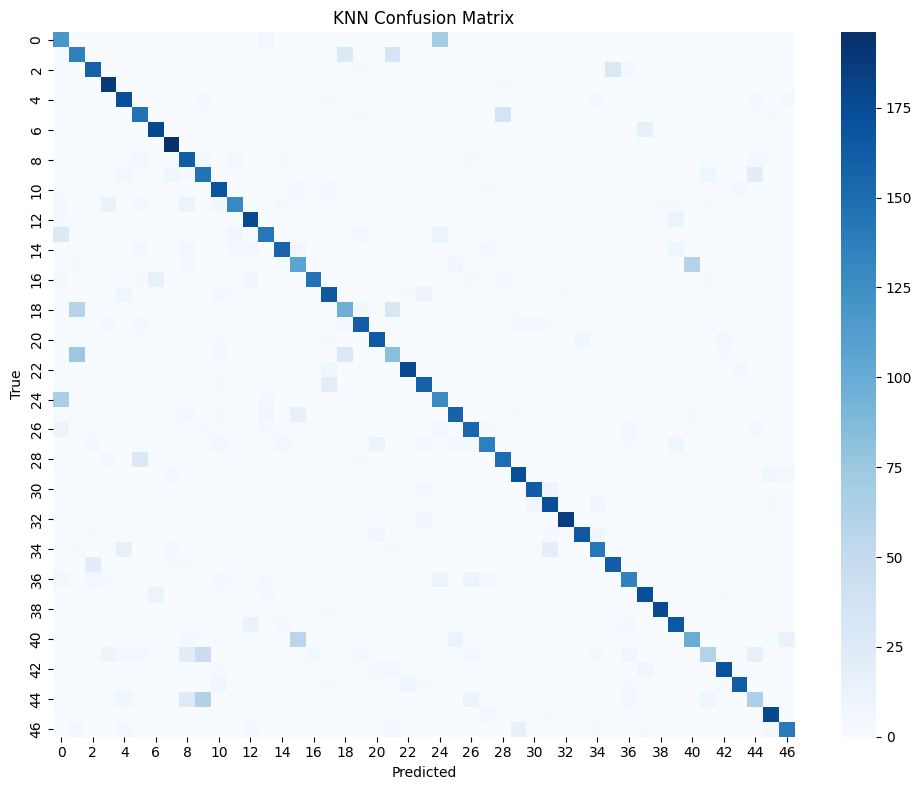

--- SVM ---
              precision    recall  f1-score   support

           0       0.59      0.61      0.60       200
           1       0.53      0.68      0.59       200
           2       0.83      0.83      0.83       200
           3       0.95      0.93      0.94       200
           4       0.85      0.85      0.85       200
           5       0.86      0.77      0.81       200
           6       0.89      0.86      0.88       200
           7       0.94      0.94      0.94       200
           8       0.83      0.81      0.82       200
           9       0.63      0.69      0.66       200
          10       0.86      0.88      0.87       200
          11       0.42      0.88      0.57       200
          12       0.93      0.89      0.91       200
          13       0.79      0.83      0.81       200
          14       0.90      0.83      0.87       200
          15       0.55      0.51      0.53       200
          16       0.90      0.79      0.84       200
          17   

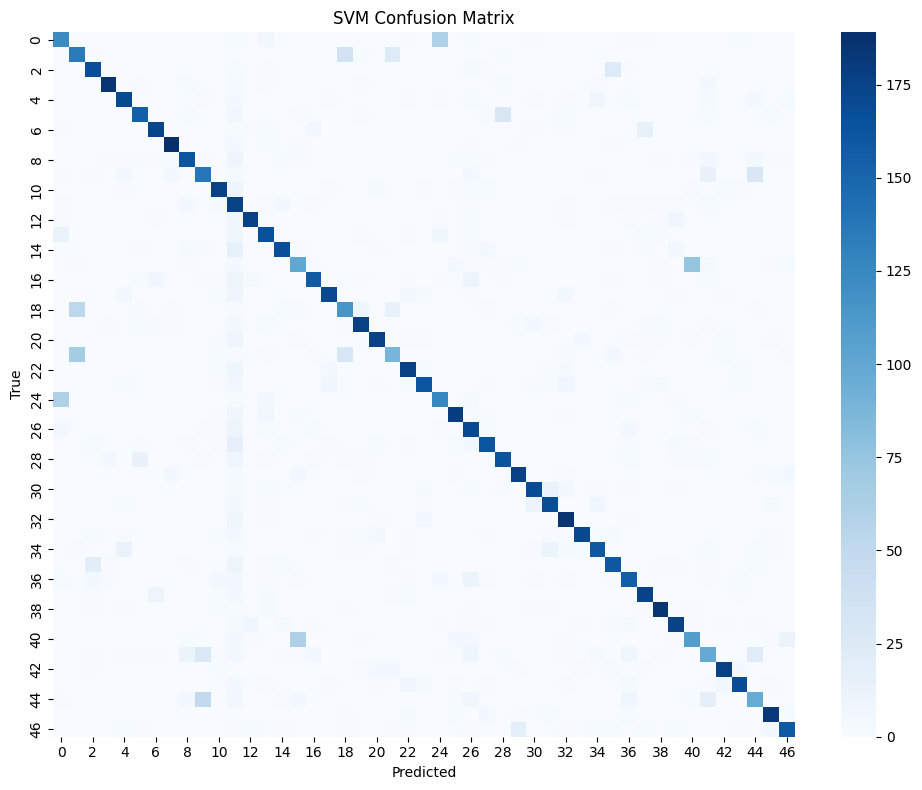

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.58      0.67      0.62       200
           1       0.53      0.63      0.57       200
           2       0.79      0.76      0.77       200
           3       0.85      0.89      0.87       200
           4       0.74      0.77      0.75       200
           5       0.73      0.64      0.68       200
           6       0.82      0.85      0.84       200
           7       0.84      0.95      0.89       200
           8       0.72      0.72      0.72       200
           9       0.60      0.74      0.66       200
          10       0.75      0.73      0.74       200
          11       0.68      0.74      0.71       200
          12       0.82      0.85      0.84       200
          13       0.71      0.74      0.72       200
          14       0.78      0.80      0.79       200
          15       0.60      0.48      0.54       200
          16       0.83      0.74      0.78       200
     

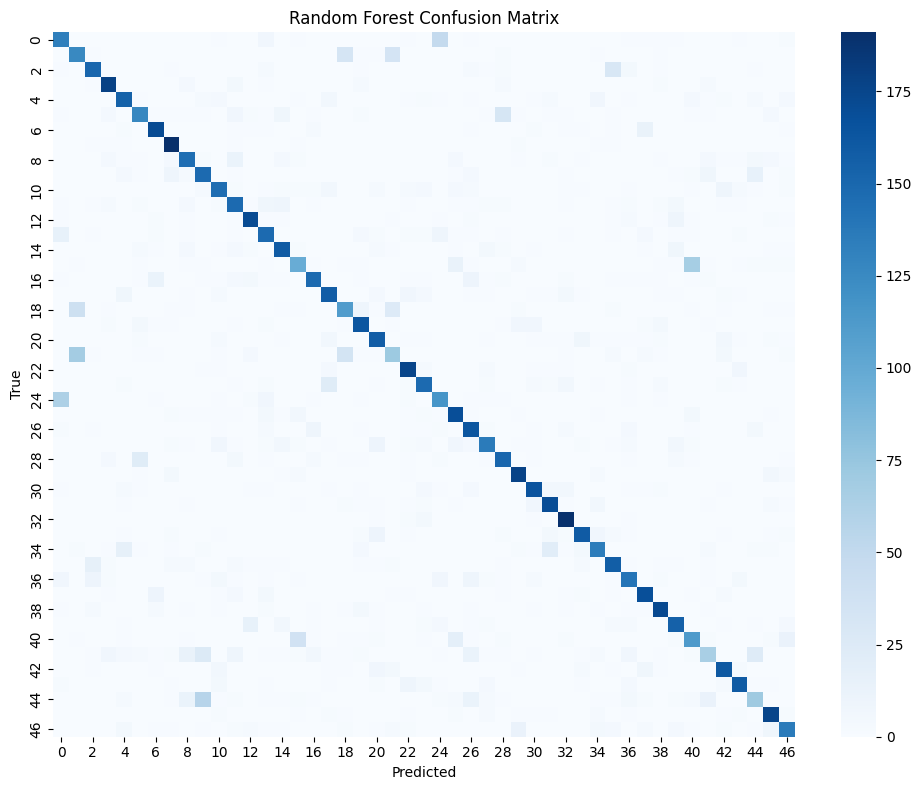

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.40      0.38      0.39       200
           1       0.43      0.40      0.41       200
           2       0.48      0.47      0.48       200
           3       0.59      0.61      0.60       200
           4       0.38      0.37      0.37       200
           5       0.40      0.36      0.38       200
           6       0.58      0.62      0.60       200
           7       0.65      0.69      0.67       200
           8       0.37      0.37      0.37       200
           9       0.42      0.44      0.43       200
          10       0.43      0.41      0.42       200
          11       0.42      0.45      0.43       200
          12       0.58      0.57      0.57       200
          13       0.43      0.41      0.42       200
          14       0.41      0.41      0.41       200
          15       0.34      0.33      0.33       200
          16       0.53      0.46      0.49       200
     

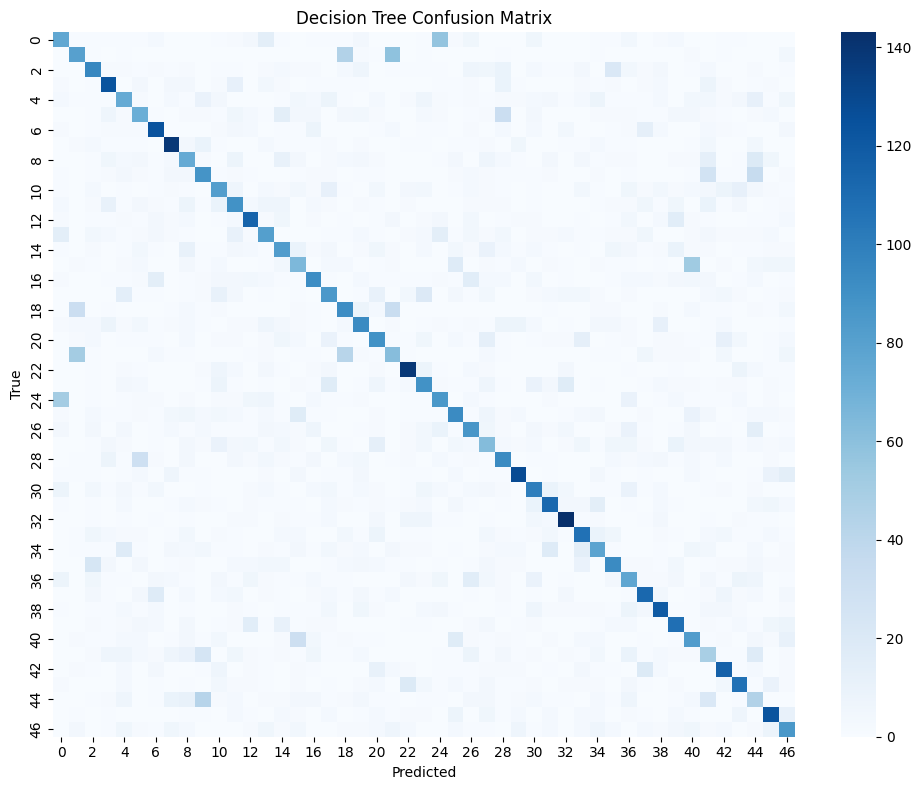

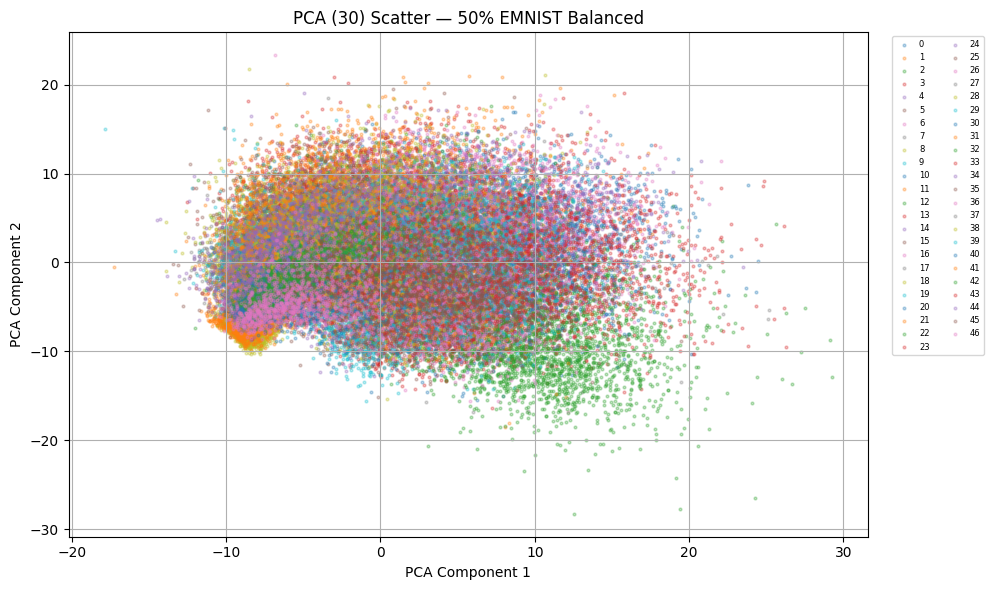

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torchvision.datasets import EMNIST
from torchvision import transforms
from torch.utils.data import DataLoader

# Load EMNIST Balanced dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
test_dataset = EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
train_images, train_labels = next(iter(train_loader))
test_images, test_labels = next(iter(test_loader))

X_train = train_images.view(train_images.shape[0], -1).numpy() / 255.0
X_test = test_images.view(test_images.shape[0], -1).numpy() / 255.0
y_train = train_labels.numpy()
y_test = test_labels.numpy()

# Subsample 50% of the data (stratified)
X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, test_size=0.5, stratify=y_train, random_state=42)
X_test_sub, _, y_test_sub, _ = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)

# Standardize and PCA (reduced to 30 components)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_sub)
X_test_std = scaler.transform(X_test_sub)

pca = PCA(n_components=30)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# Train & Evaluate Models
results = {}
predictions = {}

# Logistic Regression
logreg = LogisticRegression(max_iter=200, solver='saga', multi_class='multinomial')
logreg.fit(X_train_pca, y_train_sub)
y_pred_logreg = logreg.predict(X_test_pca)
results['Logistic Regression'] = accuracy_score(y_test_sub, y_pred_logreg)
predictions['Logistic Regression'] = y_pred_logreg

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train_sub)
y_pred_knn = knn.predict(X_test_pca)
results['KNN'] = accuracy_score(y_test_sub, y_pred_knn)
predictions['KNN'] = y_pred_knn

# SVM
svm = SVC(kernel='rbf', C=10, gamma=0.01)
svm.fit(X_train_pca, y_train_sub)
y_pred_svm = svm.predict(X_test_pca)
results['SVM'] = accuracy_score(y_test_sub, y_pred_svm)
predictions['SVM'] = y_pred_svm

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_pca, y_train_sub)
y_pred_rf = rf.predict(X_test_pca)
results['Random Forest'] = accuracy_score(y_test_sub, y_pred_rf)
predictions['Random Forest'] = y_pred_rf

# Decision Tree
dt = DecisionTreeClassifier(max_depth=25, random_state=42)
dt.fit(X_train_pca, y_train_sub)
y_pred_dt = dt.predict(X_test_pca)
results['Decision Tree'] = accuracy_score(y_test_sub, y_pred_dt)
predictions['Decision Tree'] = y_pred_dt

# Accuracy Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylim(0.3, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Accuracy on 50% EMNIST Balanced (PCA = 30)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Confusion Matrix Function
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# Evaluate All Models
for model_name, y_pred in predictions.items():
    evaluate_model(model_name, y_test_sub, y_pred)

# PCA Scatter Visualization
def plot_pca_scatter(X_pca, y, title):
    plt.figure(figsize=(10, 6))
    for label in np.unique(y):
        idx = y == label
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=str(label), s=4, alpha=0.3)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), ncol=2, fontsize=6)
    plt.tight_layout()
    plt.show()

plot_pca_scatter(X_train_pca, y_train_sub, "PCA (30) Scatter — 50% EMNIST Balanced")


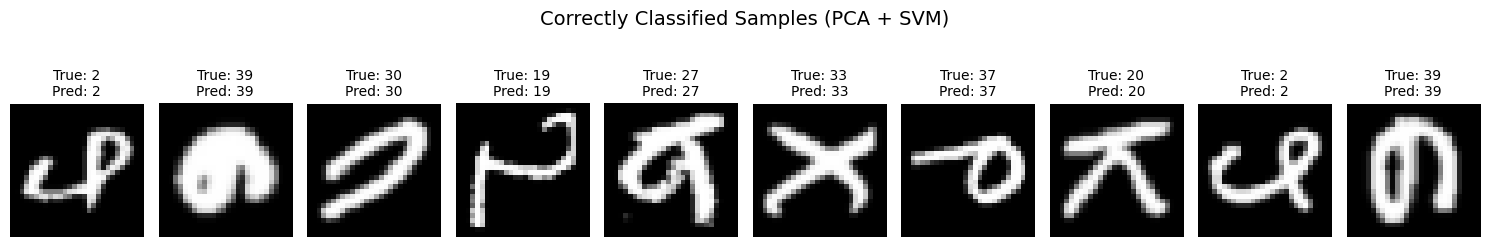

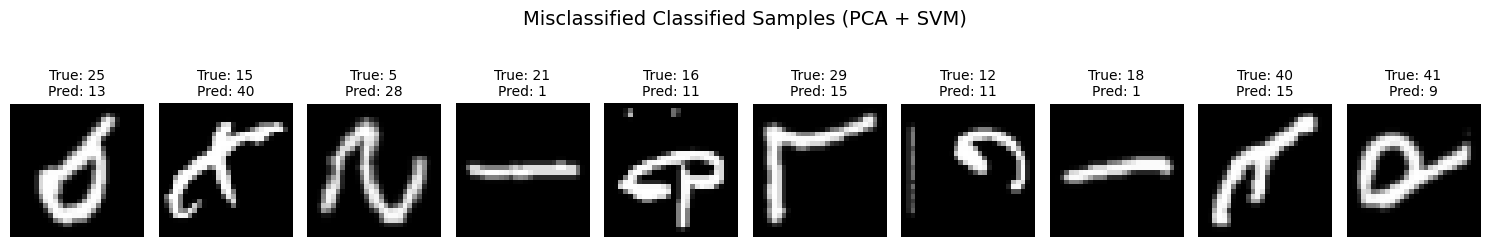

In [ ]:
# Show 5 classified or misclassified samples with true/pred labels
def show_classified_samples(images, y_true, y_pred, correct=True, num_samples=10):

    match = y_true == y_pred if correct else y_true != y_pred
    indices = np.where(match)[0]

    if len(indices) == 0:
        print("No samples to display.")
        return

    selected = np.random.choice(indices, min(num_samples, len(indices)), replace=False)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(selected):
        plt.subplot(1, num_samples, i + 1)
        img = images[idx].reshape(28, 28)  # ✅ reshape to 28x28
        plt.imshow(img, cmap="gray")
        plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}", fontsize=10)
        plt.axis("off")
    status = "Correctly" if correct else "Misclassified"
    plt.suptitle(f"{status} Classified Samples (PCA + SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()

show_classified_samples(X_test_sub, y_test_sub, y_pred_svm, correct=True)
show_classified_samples(X_test_sub, y_test_sub, y_pred_svm, correct=False)


## EMNIST - letters dataset



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


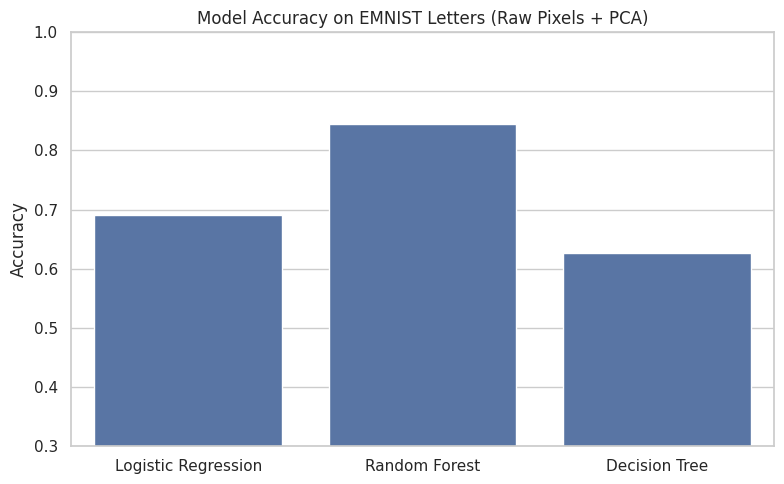

--- Logistic Regression ---
              precision    recall  f1-score   support

           a       0.57      0.57      0.57       800
           b       0.71      0.71      0.71       800
           c       0.76      0.77      0.77       800
           d       0.64      0.61      0.62       800
           e       0.74      0.72      0.73       800
           f       0.72      0.73      0.72       800
           g       0.58      0.47      0.52       800
           h       0.63      0.63      0.63       800
           i       0.58      0.62      0.60       800
           j       0.70      0.73      0.72       800
           k       0.63      0.65      0.64       800
           l       0.54      0.57      0.56       800
           m       0.86      0.90      0.88       800
           n       0.64      0.62      0.63       800
           o       0.81      0.89      0.85       800
           p       0.78      0.83      0.81       800
           q       0.60      0.58      0.59       800

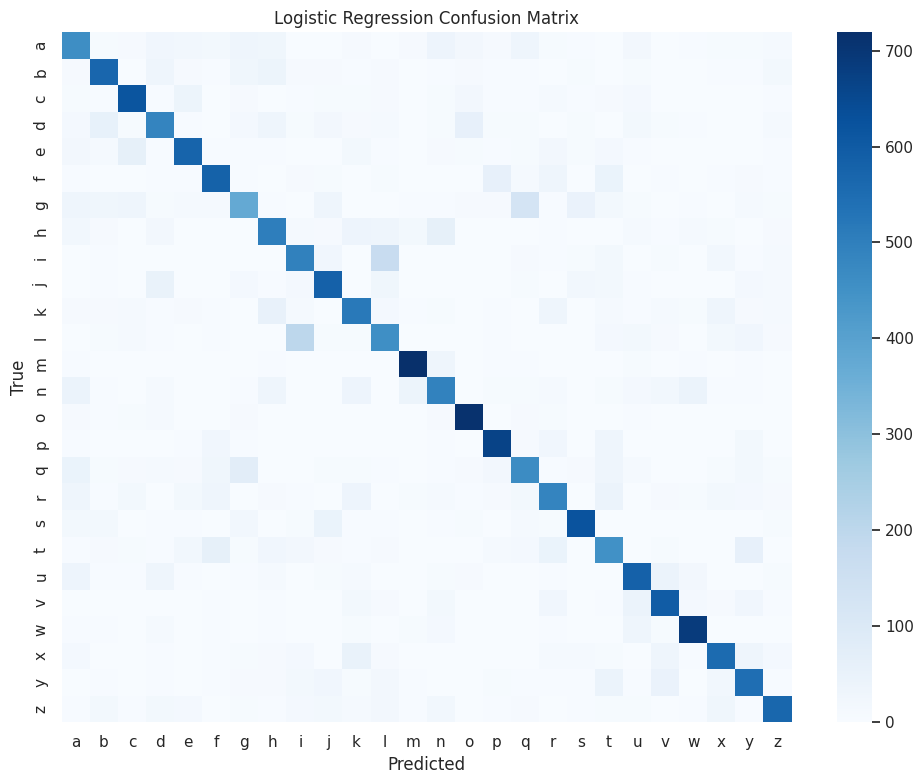

--- Random Forest ---
              precision    recall  f1-score   support

           a       0.78      0.81      0.80       800
           b       0.84      0.86      0.85       800
           c       0.87      0.91      0.89       800
           d       0.85      0.83      0.84       800
           e       0.87      0.85      0.86       800
           f       0.88      0.84      0.86       800
           g       0.79      0.66      0.72       800
           h       0.85      0.80      0.82       800
           i       0.72      0.71      0.71       800
           j       0.86      0.88      0.87       800
           k       0.77      0.84      0.81       800
           l       0.73      0.70      0.71       800
           m       0.89      0.93      0.91       800
           n       0.83      0.82      0.82       800
           o       0.87      0.95      0.91       800
           p       0.86      0.92      0.89       800
           q       0.72      0.74      0.73       800
     

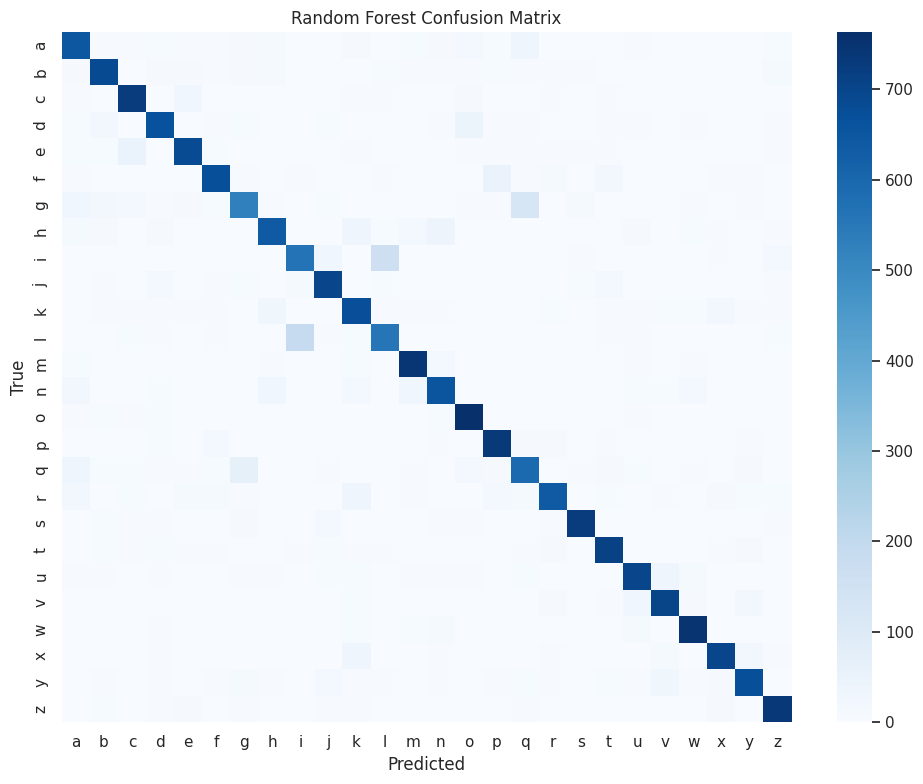

--- Decision Tree ---
              precision    recall  f1-score   support

           a       0.48      0.51      0.50       800
           b       0.58      0.58      0.58       800
           c       0.66      0.65      0.65       800
           d       0.63      0.58      0.60       800
           e       0.63      0.64      0.63       800
           f       0.64      0.59      0.61       800
           g       0.43      0.44      0.43       800
           h       0.59      0.60      0.59       800
           i       0.55      0.56      0.56       800
           j       0.65      0.65      0.65       800
           k       0.62      0.59      0.60       800
           l       0.55      0.56      0.56       800
           m       0.81      0.80      0.80       800
           n       0.60      0.57      0.59       800
           o       0.74      0.77      0.75       800
           p       0.71      0.71      0.71       800
           q       0.47      0.46      0.46       800
     

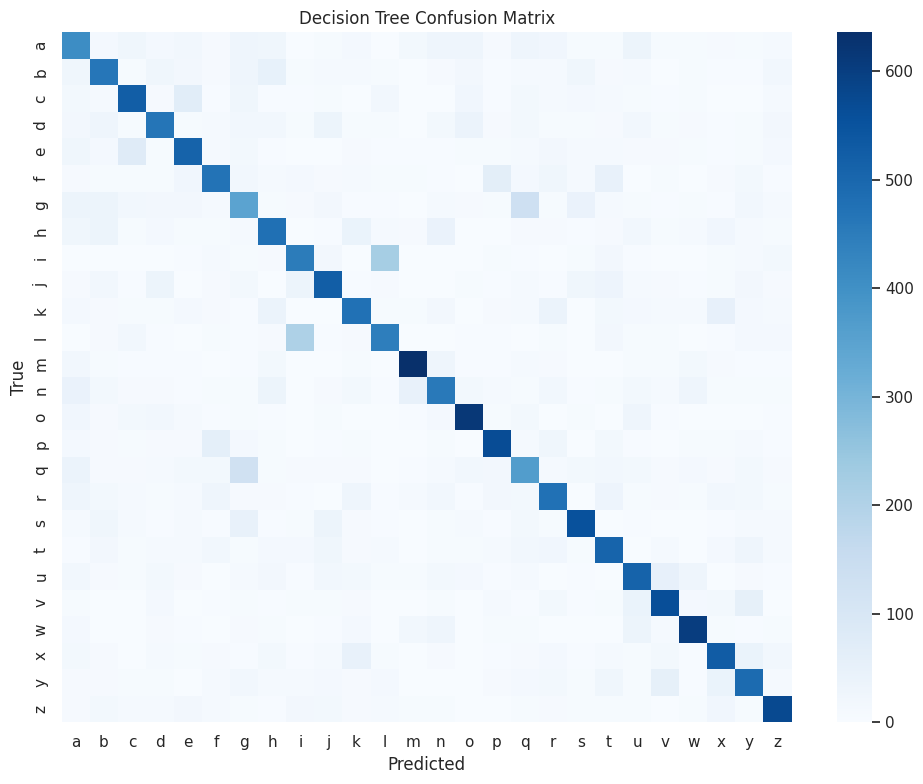

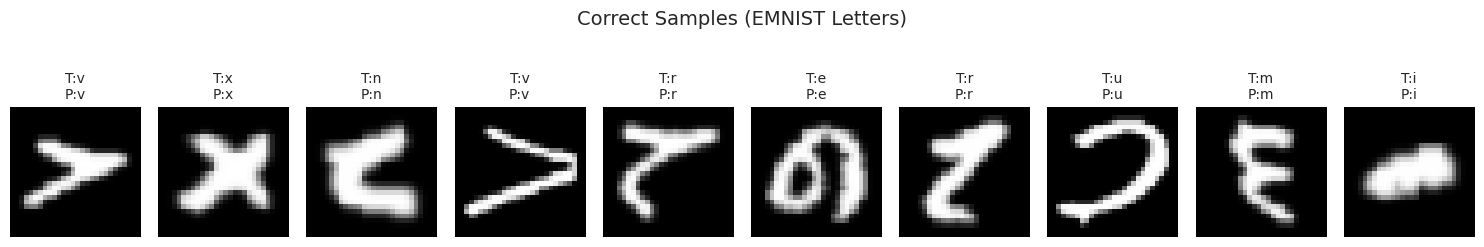

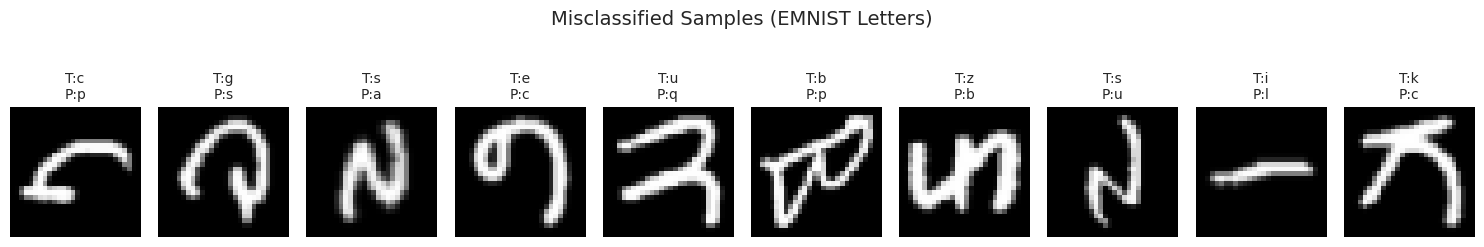

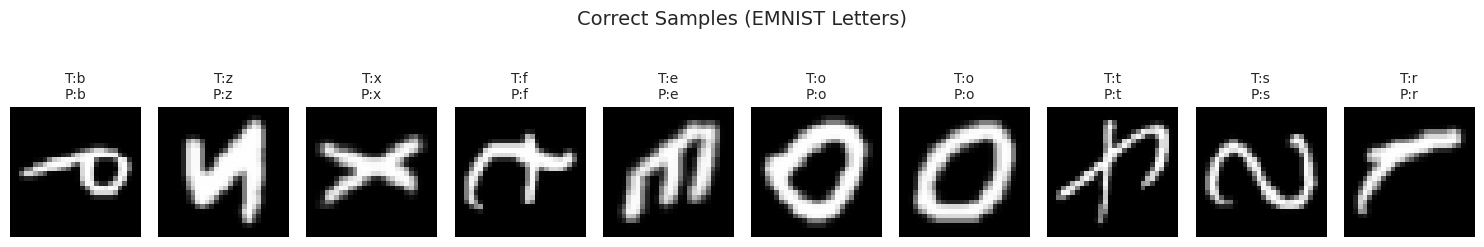

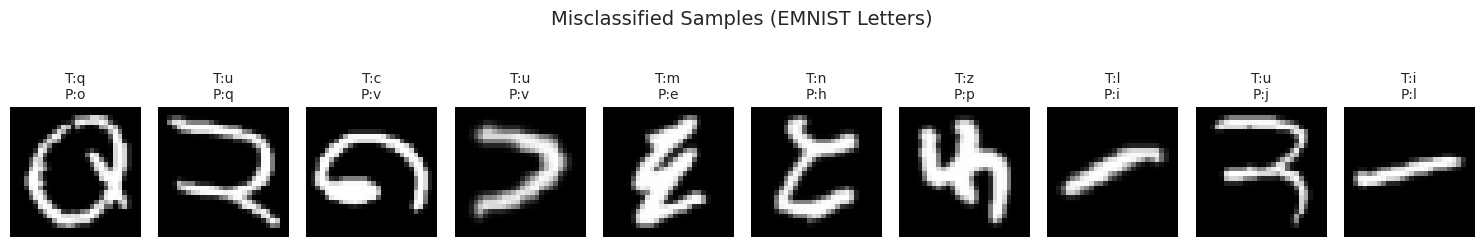

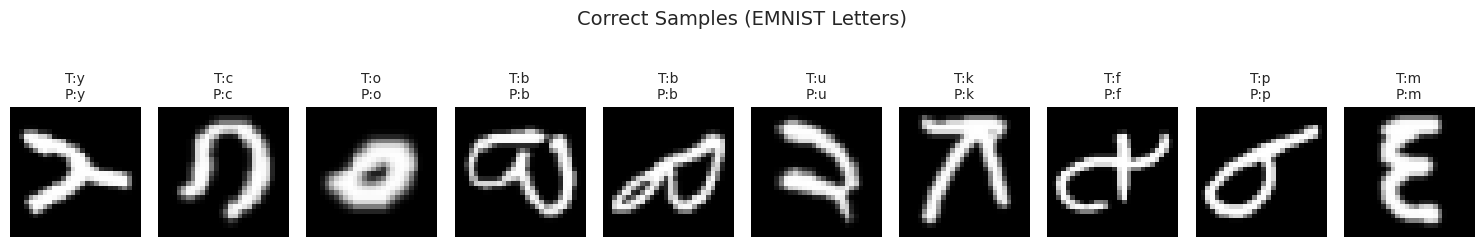

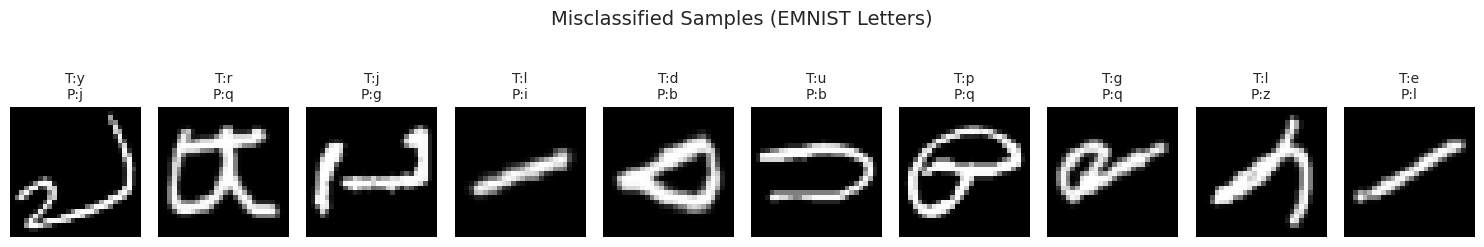

In [ ]:
# Load EMNIST Letters dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from torchvision.datasets import EMNIST
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = EMNIST(root="./data", split="letters", train=True, download=True, transform=transform)
test_dataset = EMNIST(root="./data", split="letters", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

train_images, train_labels = next(iter(train_loader))
test_images, test_labels = next(iter(test_loader))

# Flatten images and normalize
X_train = train_images.view(train_images.shape[0], -1).numpy() / 255.0
X_test = test_images.view(test_images.shape[0], -1).numpy() / 255.0

# Adjust labels: EMNIST Letters labels are from 1–26, shift to 0–25
y_train = train_labels.numpy() - 1
y_test = test_labels.numpy() - 1
label_map = [chr(ord('a') + i) for i in range(26)]

# Standardize and apply PCA
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# Train models
results = {}

def train_and_evaluate(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (acc, y_pred)
    return y_pred

y_pred_logreg = train_and_evaluate("Logistic Regression", LogisticRegression(max_iter=200), X_train_pca, y_train, X_test_pca, y_test)
y_pred_rf = train_and_evaluate("Random Forest", RandomForestClassifier(n_estimators=100), X_train_pca, y_train, X_test_pca, y_test)
y_pred_dt = train_and_evaluate("Decision Tree", DecisionTreeClassifier(max_depth=25), X_train_pca, y_train, X_test_pca, y_test)

# Accuracy Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=[v[0] for v in results.values()])
plt.ylim(0.3, 1.0)
plt.title("Model Accuracy on EMNIST Letters (Raw Pixels + PCA)")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Confusion Matrix for Logistic Regression
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, target_names=label_map))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", xticklabels=label_map, yticklabels=label_map)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

evaluate_model("Logistic Regression", y_test, y_pred_logreg)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Decision Tree", y_test, y_pred_dt)

# Show correct or incorrect classifications
def show_classified_samples(images, y_true, y_pred, label_map, correct=True, num_samples=10):
    match = y_true == y_pred if correct else y_true != y_pred
    indices = np.where(match)[0]

    if len(indices) == 0:
        print("No samples to display.")
        return

    selected = np.random.choice(indices, min(num_samples, len(indices)), replace=False)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(selected):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[idx].reshape(28, 28), cmap="gray")
        true_char = label_map[y_true[idx]]
        pred_char = label_map[y_pred[idx]]
        plt.title(f"T:{true_char}\nP:{pred_char}", fontsize=10)
        plt.axis("off")
    status = "Correct" if correct else "Misclassified"
    plt.suptitle(f"{status} Samples (EMNIST Letters)", fontsize=14)
    plt.tight_layout()
    plt.show()

show_classified_samples(X_test, y_test, y_pred_logreg, label_map, correct=True)
show_classified_samples(X_test, y_test, y_pred_logreg, label_map, correct=False)

show_classified_samples(X_test, y_test, y_pred_dt, label_map, correct=True)
show_classified_samples(X_test, y_test, y_pred_dt, label_map, correct=False)

show_classified_samples(X_test, y_test, y_pred_rf, label_map, correct=True)
show_classified_samples(X_test, y_test, y_pred_rf, label_map, correct=False)

## CNN


Using device: cpu
Epoch 1/8 — Loss: 0.5541 — Train Acc: 81.53%
Epoch 2/8 — Loss: 0.4123 — Train Acc: 85.20%
Epoch 3/8 — Loss: 0.3869 — Train Acc: 85.87%
Epoch 4/8 — Loss: 0.3731 — Train Acc: 86.22%
Epoch 5/8 — Loss: 0.3642 — Train Acc: 86.47%
Epoch 6/8 — Loss: 0.3573 — Train Acc: 86.69%
Epoch 7/8 — Loss: 0.3518 — Train Acc: 86.80%
Epoch 8/8 — Loss: 0.3472 — Train Acc: 86.97%
CNN Test Accuracy on EMNIST: 79.69%


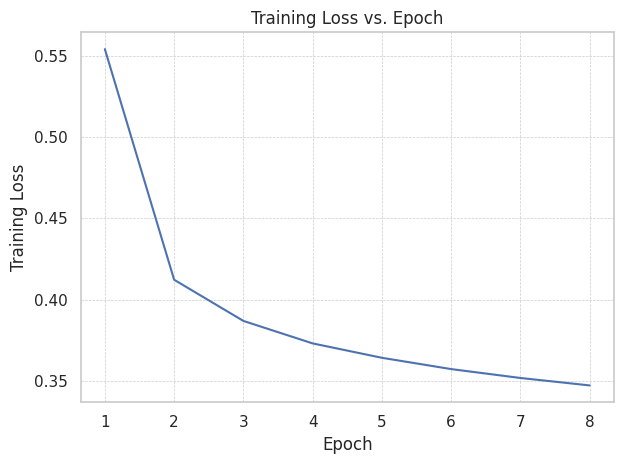

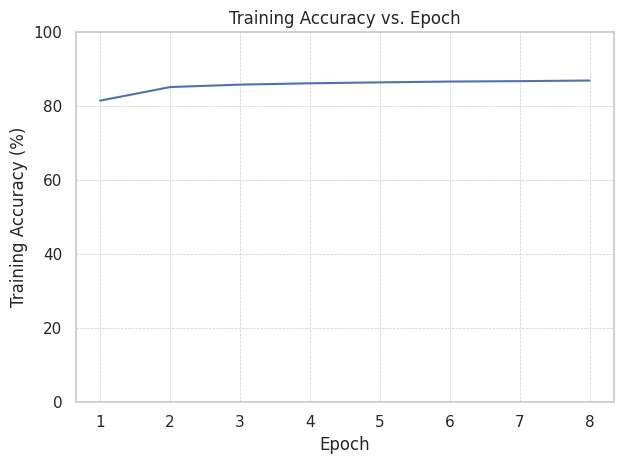

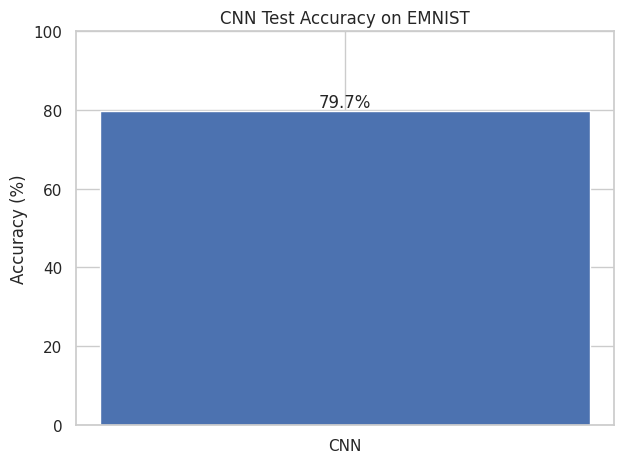

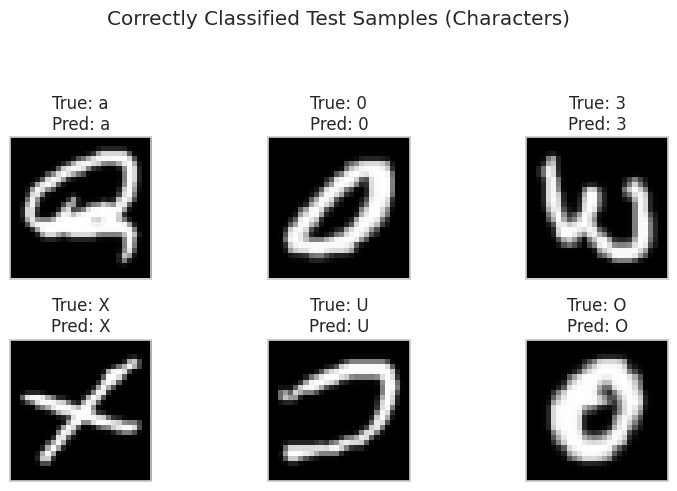

In [ ]:
# Imports
!pip install torch torchvision scikit-learn kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import string

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
print(f'Using device: {device}')

# EMNIST ByClass contains 62 classes: 10 digits + 26 uppercase + 26 lowercase
emnist_byclass_mapping = list(string.digits + string.ascii_uppercase + string.ascii_lowercase)
emnist_byclass_mapping = list(string.digits + string.ascii_uppercase + string.ascii_lowercase)

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='byclass', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='byclass', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

# Define CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 16, 3, 1)
        self.conv2   = nn.Conv2d(16, 32, 3, 1)
        self.fc1     = nn.Linear(5*5*32, 128)
        self.fc2     = nn.Linear(128, 62)
        self.relu    = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.maxpool(x)
        x = self.relu(self.conv2(x))
        x = self.maxpool(x)
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model     = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
num_epochs = 8
loss_list = []
train_acc_list = []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    train_acc = 100 * running_correct / running_total
    loss_list.append(avg_loss)
    train_acc_list.append(train_acc)
    print(f"Epoch {epoch}/{num_epochs} — Loss: {avg_loss:.4f} — Train Acc: {train_acc:.2f}%")

# Testing & Collecting Correct Predictions
model.eval()
correct = 0
total = 0
correct_examples = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        # Collect up to 6 correct predictions
        mask = preds == labels
        for img, true, pred, is_corr in zip(images, labels, preds, mask):
            if is_corr:
                correct_examples.append((img.cpu(), true.cpu(), pred.cpu()))
                if len(correct_examples) >= 6:
                    break
        if len(correct_examples) >= 6:
            break

test_accuracy = 100 * correct / total
print(f'CNN Test Accuracy on EMNIST: {test_accuracy:.2f}%')

# Plot
plt.figure()
plt.plot(range(1, num_epochs + 1), loss_list)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Epoch')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("training_loss")
plt.show()

plt.figure()
plt.plot(range(1, num_epochs + 1), train_acc_list)
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.title('Training Accuracy vs. Epoch')
plt.xticks(range(1, num_epochs + 1))
plt.ylim(0, 100)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("training_acc")
plt.show()

plt.figure()
plt.bar(['CNN'], [test_accuracy])
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('CNN Test Accuracy on EMNIST')
plt.text(0, test_accuracy + 1, f"{test_accuracy:.1f}%", ha='center')
plt.tight_layout()
plt.savefig("test_acc")
plt.show()

plt.figure(figsize=(8, 5))
for i, (img, true, pred) in enumerate(correct_examples):
    true_char = emnist_byclass_mapping[true.item()]
    pred_char = emnist_byclass_mapping[pred.item()]
    plt.subplot(2, 3, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"True: {true_char}\nPred: {pred_char}")
    plt.xticks([])
    plt.yticks([])
plt.suptitle('Correctly Classified Test Samples (Characters)')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("cnnsamples")
plt.show()


In [ ]:
# Extract CNN features before final FC layer
def extract_features(model, loader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            x = model.relu(model.conv1(images))
            x = model.maxpool(x)
            x = model.relu(model.conv2(x))
            x = model.maxpool(x)
            x = torch.flatten(x, 1)
            x = model.relu(model.fc1(x))  # Pre-logit features
            features.append(x.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(labels)

cnn_features, cnn_labels = extract_features(model, test_loader)


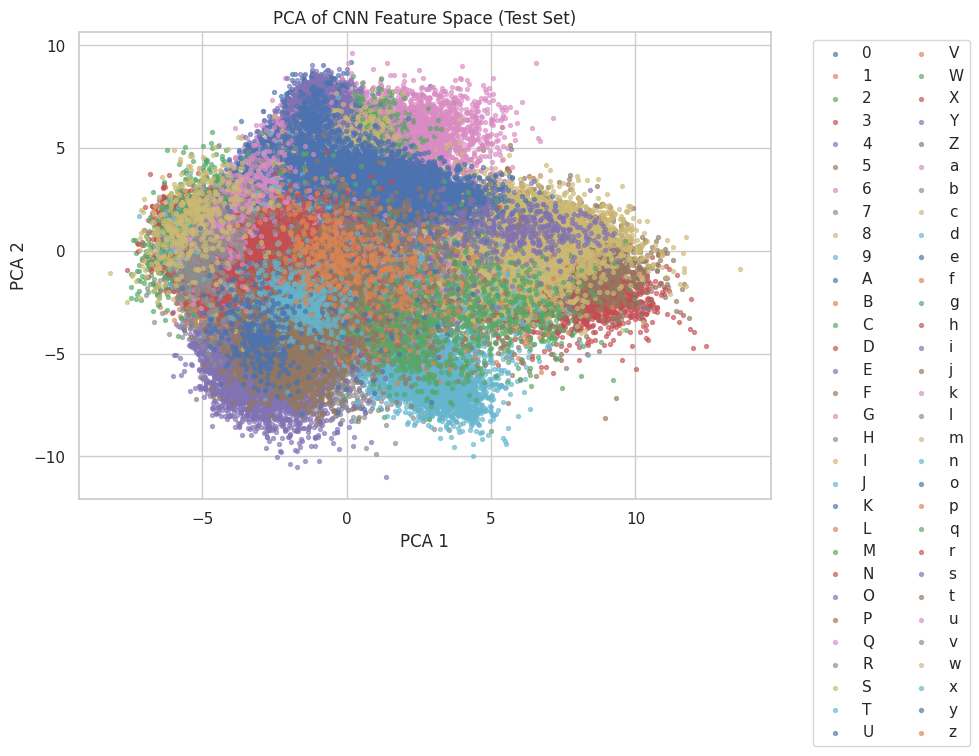

In [ ]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
features_2d = pca_2d.fit_transform(cnn_features)

plt.figure(figsize=(10, 7))
for label in np.unique(cnn_labels):
    idx = cnn_labels == label
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1], label=emnist_byclass_mapping[label], s=8, alpha=0.6)
plt.title("PCA of CNN Feature Space (Test Set)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_features")
plt.show()


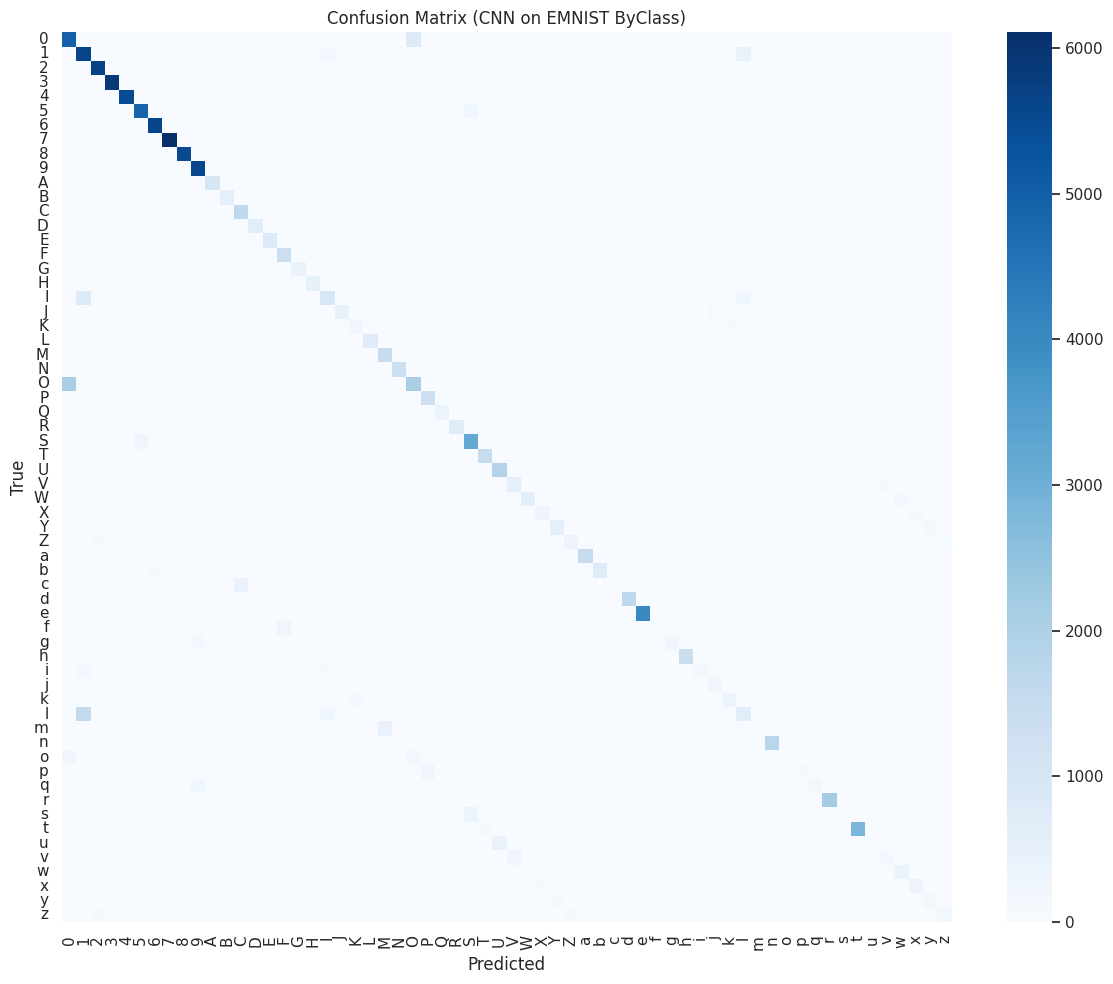

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 🧾 Collect predictions for confusion matrix
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# 📉 Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=emnist_byclass_mapping, yticklabels=emnist_byclass_mapping)
plt.title("Confusion Matrix (CNN on EMNIST ByClass)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("conf_matrix")
plt.show()



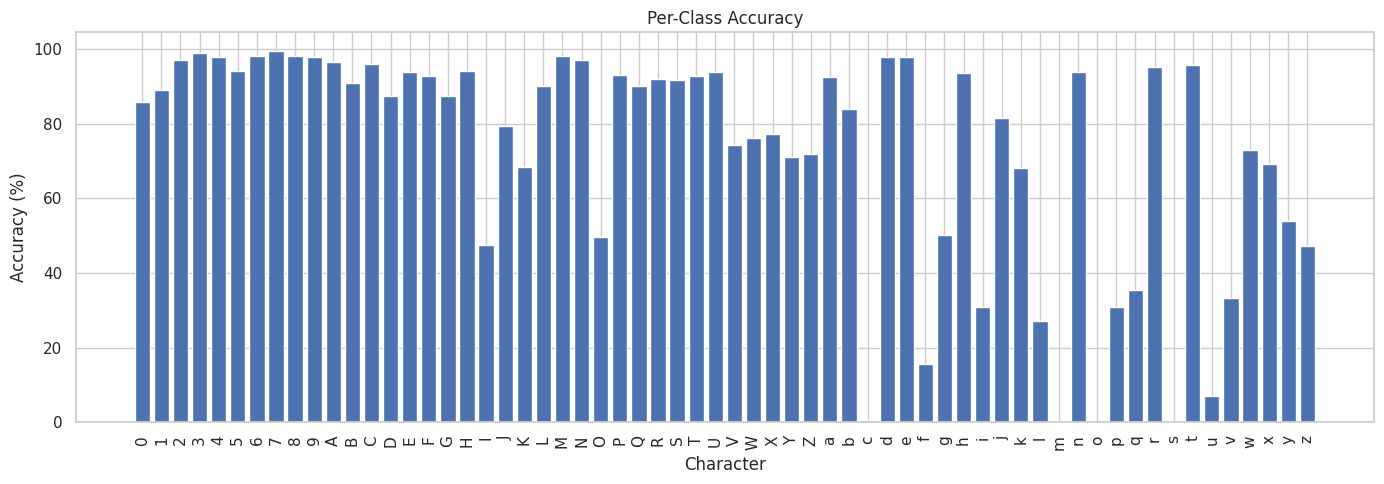

In [ ]:
correct_per_class = np.zeros(62)
total_per_class = np.zeros(62)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        for i in range(len(labels)):
            total_per_class[labels[i]] += 1
            if preds[i] == labels[i]:
                correct_per_class[labels[i]] += 1

accuracy_per_class = 100 * correct_per_class / total_per_class

plt.figure(figsize=(14, 5))
plt.bar(emnist_byclass_mapping, accuracy_per_class)
plt.title("Per-Class Accuracy")
plt.xlabel("Character")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("per_class_accuracy")
plt.show()
